#**Capstone project: Can ML Outperform Market-Neutral Trading in Structural Breaks?**

**Note:**

It's a good practise to "restart the session", whenever changes are made to the github repository


##**Step 1:** GitHub setup

1) Clone/Update the projects github repository

In [1]:
# Use for the first time to clone the github repo or when the repo is updated
%rm -rf /content/MarketNeutral_Trading/
%cd /content
!git clone https://github.com/WQU-Capstone-11205/MarketNeutral_Trading.git
%cd /content/MarketNeutral_Trading

/content
Cloning into 'MarketNeutral_Trading'...
remote: Enumerating objects: 916, done.
remote: Counting objects: 100% (156/156), done.
remote: Compressing objects: 100% (152/152), done.
remote: Total 916 (delta 90), reused 4 (delta 4), pack-reused 760 (from 2)
Receiving objects: 100% (916/916), 1.51 MiB | 17.82 MiB/s, done.
Resolving deltas: 100% (509/509), done.
/content/MarketNeutral_Trading


2) Add the project's github repository's path to the system path

In [2]:
import warnings
warnings.filterwarnings('ignore')
import sys
sys.path.append('/content/MarketNeutral_Trading')

3) Install projects required packages

In [3]:
!pip install -r requirements.txt

##**Step 2:** Data loading

Load data and convert to distance spread

In [4]:
from data_loading.fetch_data import fetch_from_yfinance
from data_loading.distance_spread import distance_spread
from util.split_time_series import split_time_series
from util.ff_benchmark import get_ff_benchmark_returns

# Example pair: XLF and FAS (Financial sector ETFs, often cointegrated)
ticker1 = 'XLF'
ticker2 = 'FAS'# Note: FAS is a leveraged ETF, may require careful handling/interpretation
start_date = '2005-01-01'
end_date = '2025-01-01'
# Use an in-sample period for training the cointegration relationship
in_sample_cutoff_date = '2017-01-01' # After this date the cointegration fails

# Fetch a benchmark for alpha/beta calculation (e.g., SPY)
benchmark_data = fetch_from_yfinance(['SPY'], start_date, end_date)
benchmark_returns = benchmark_data.pct_change().dropna()
train_spy_returns = benchmark_returns.loc[:in_sample_cutoff_date]
test_spy_returns = benchmark_returns.loc[in_sample_cutoff_date:]
ff_benchmark_returns = get_ff_benchmark_returns(in_sample_cutoff_date, end_date)

spread = distance_spread([ticker1, ticker2], start_date=start_date, end_date=end_date)
train_spread = spread.loc[:in_sample_cutoff_date]
test_spread = spread.loc[in_sample_cutoff_date:]
spread_returns = spread.pct_change().dropna()
train_spread_returns = spread_returns.loc[:in_sample_cutoff_date]
test_spread_returns = spread_returns.loc[in_sample_cutoff_date:]

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  2 of 2 completed


##**Step 3:** Hyperparameter tuning of BOCPD+VAE+TRAFO pipeline

Tune hyper-parameter for BOCPD+VAE+TRAFO pipeline.

In [5]:
bocpd_space = {
    "hazard": [50],
    "mu": [0],
    "kappa": [0.1],
    "alpha": [1.0],
    "beta": [0.1]
}

vae_space = {
    "input_dim": [2],
    "latent_dim": [12],
    "hidden_dim": [128],
    "lr": [0.001],
    "vae_seq_len": [1],
    "kl_wt": [0.001]
}

trafo_space = {
    "z_dim": [12],
    "d_model": [12],
    "nhead": [4],
    "num_layers": [1],
    "hidden_dim": [4], #"2*d_model", "3*d_model", "4*d_model"
    "lr": [0.0003],
    "gamma": [0.99]
}

joint_space = {
    "state_window": [50],
    "base_action_sigma": [0.01],
    "wt_multplier": [1.5],
    "buffer_size_updates": [64],
    "sample_batch_size": [16],
    "transaction_cost": [0.01]
}

from tuning.bocpd_vae_trafo_tuner import BOCPD_VAE_TRAFO_Tuner

bocpd_vae_trafo_tuner = BOCPD_VAE_TRAFO_Tuner(bocpd_space, vae_space, trafo_space, joint_space)
#bocpd_vae_trafo_tuner = BOCPD_VAE_TRAFO_Tuner()

bocpd_vae_trafo_tuner.tune(train_spread)
bocpd_params, vae_params, trafo_params, joint_params = bocpd_vae_trafo_tuner.best_params

print(f'bocpd_params = {bocpd_params}')
print(f'vae_params = {vae_params}')
print(f'trafo_params = {trafo_params}')
print(f'joint_params = {joint_params}')
# It takes 8 hours for full tuning

bocpd score = -20 :: params = {'hazard': 50, 'mu': 0, 'kappa': 0.1, 'alpha': 1.0, 'beta': 0.1}
Best BOCPD parameters: {'hazard': 50, 'mu': 0, 'kappa': 0.1, 'alpha': 1.0, 'beta': 0.1}
Best BOCPD score: -20
vae score = -50.4068 :: params = {'input_dim': 2, 'latent_dim': 12, 'hidden_dim': 128, 'lr': 0.001, 'vae_seq_len': 1, 'kl_wt': 0.001}
Best vae parameters: {'input_dim': 2, 'latent_dim': 12, 'hidden_dim': 128, 'lr': 0.001, 'vae_seq_len': 1, 'kl_wt': 0.001}
Best vae score: -50.4068
Transformer score = 0.3263 :: params = {'z_dim': 12, 'd_model': 12, 'nhead': 4, 'num_layers': 1, 'hidden_dim': 4, 'lr': 0.0003, 'gamma': 0.99}
Best Transformer parameters: {'z_dim': 12, 'd_model': 12, 'nhead': 4, 'num_layers': 1, 'hidden_dim': 4, 'lr': 0.0003, 'gamma': 0.99}
Best Transformer score: 0.3263
Joint Tuning score = 0.3263 :: params = {'state_window': 50, 'base_action_sigma': 0.01, 'wt_multplier': 1.5, 'buffer_size_updates': 64, 'sample_batch_size': 16, 'transaction_cost': 0.01}
Best Joint Tuning pa

First we tuned with the BOCPD_VAE_TRAFO_Tuner.tune(). It was found that sharpe ratio of evalution loop was not upto the mark and also had an higher drawdown. So, we manually adjusted the hidden dimensions of TRAFO till the results were better.

The best parameters are now stored in the BOCPD_VAE_TRAFO_Tuner class. These can directly be used without tuning the model again. The model's complete automatic tuning takes roughly around 10 hours.

##**Step 4:** Training of BOCPD+VAE+TRAFO pipeline

This task takes around 70 minutes.

In [6]:
from train.train_loop_transformer import train_loop_trafo

train_loop_trafo(train_spread, bocpd_params, vae_params, trafo_params, joint_params, num_epochs=25)

100%|██████████| 2042/2042 [00:29<00:00, 68.83it/s]


Epoch 000 | recon=0.0246 | kl=0.0461 | policy=-0.0757
Train Epoch Sharpe=-0.928
Saved all models + optimizers
Saved best models at epoch 000 (Train Sharpe=-0.928)


100%|██████████| 2042/2042 [00:31<00:00, 65.85it/s]


Stop-loss triggered for 195 PnLs
Epoch 001 | recon=0.0009 | kl=0.2362 | policy=0.0033
Train Epoch Sharpe=-0.742
Saved all models + optimizers
Saved best models at epoch 001 (Train Sharpe=-0.742)


100%|██████████| 2042/2042 [00:33<00:00, 61.38it/s]


...

Stop-loss triggered for 207 PnLs
Epoch 004 | recon=0.0011 | kl=0.1346 | policy=0.0053
Train Epoch Sharpe=-1.005
No improvement. Early stopping patience counter = 3/5


100%|██████████| 2042/2042 [00:35<00:00, 57.90it/s]


Stop-loss triggered for 259 PnLs
Epoch 005 | recon=0.0005 | kl=0.1341 | policy=0.0068
Train Epoch Sharpe=-1.055
No improvement. Early stopping patience counter = 4/5


100%|██████████| 2042/2042 [00:36<00:00, 56.05it/s]

Stop-loss triggered for 298 PnLs
Epoch 006 | recon=0.0005 | kl=0.1094 | policy=0.0061
Train Epoch Sharpe=-1.364
No improvement. Early stopping patience counter = 5/5
EARLY STOPPING TRIGGERED at epoch 6
Training stopped early due to no improvement in Sharpe.
Transformer policy training complete.


##**Step 5:** Testing of BOCPD+VAE+Transformer pipeline:

In [7]:
from backtest.evaluate_loop_trafo import evaluate_loop_trafo

test_metrics = evaluate_loop_trafo(test_spread, bocpd_params, vae_params, trafo_params, joint_params)

Loaded models/opts


100%|██████████| 2011/2011 [00:07<00:00, 260.57it/s]


RMSE channel0 (spread, denorm): 0.508999
RMSE channel1 (cp prob):        0.081287

Evaluation complete.


##**Step 6:** Test metrics BOCPD+VAE+Transformer pipeline:

In [8]:
import numpy as np
from util.metrics import sharpe_ratio, compute_max_drawdown, sortino_ratio, annual_volatility, alpha_beta

print("Test metrics for BOCPD+VAE+Transformer model:")
cum_pnl = np.cumsum(test_metrics['portfolio_returns'])
print(f"Cummulative profit and loss                       : {cum_pnl[-1]:.6f}")
print(f"Sharpe Ratio                                      : {sharpe_ratio(test_metrics['portfolio_returns']):.6f}")
print(f"Sortino ratio                                     : {sortino_ratio(test_metrics['portfolio_returns']):.6f}")
print(f"Max drawdown                                      : {compute_max_drawdown(np.cumsum(test_metrics['portfolio_returns'])):.6f}")
print(f"Annual Volatility                                 : {annual_volatility(test_metrics['portfolio_returns']):.6f}")
alpha_ff, beta_ff = alpha_beta(test_metrics['portfolio_returns'], ff_benchmark_returns)
print(f"Factor-adjusted Alpha-Beta                        : alpha = {alpha_ff:.6f} , beta = {beta_ff:.6f}")
alpha_spy, beta_spy = alpha_beta(test_metrics['portfolio_returns'], test_spy_returns)
print(f"CAPM Alpha-Beta versus SPY                        : alpha = {alpha_spy:.6f} , beta = {beta_spy:.6f}")

Test metrics for BOCPD+VAE+Transformer model:
Cummulative profit and loss                       : 29.064171
Sharpe Ratio                                      : 0.560368
Sortino ratio                                     : 1.259581
Max drawdown                                      : 0.264667
Annual Volatility                                 : 6.499396
Factor-adjusted Alpha-Beta                        : alpha = 3.614570 , beta = 0.205366
CAPM Alpha-Beta versus SPY                        : alpha = 3.619811 , beta = 0.143676


##**Overall Assessment:**
This model produced profitable, reasonably stable, and moderately risk-adjusted performance. The numbers show a solid strategy with good behavior during drawdowns and decent return consistency.

1. Cumulative PnL of 29.06 : Indicates the model made meaningful net profit. Combined with volatility (~6.5%), this is a healthy growth relative to risk.
2. Sharpe Ratio = 0.56 : Moderate, above 0.5 means the strategy is adding risk-adjusted value. It's still far from institutional quality (1.0+), but improvement over random/noisy trading.
3. Sortino Ratio = 1.26 : Stronger than Sharpe, meaning the model’s downside volatility is low. Loss days are smaller/more controlled.It's a good sign as the Transformer handles downside risk better than upside noise.
4. Max Drawdown = 0.26 : 26% drawdown is moderate, not extremely low, but acceptable for systematic trading on spreads with high volatility.
5. Annual Volatility = 6.49 : Very low in absolute terms.

The model trades conservatively. Actions may be clustered closer to zero (low position sizes). BOCPD + VAE smoothing reduces regime shocks.

6. Factor Regression α, β: α ≈ 3.6 (positive) in both tests → strong risk-adjusted excess return. β ≈ 0.14-0.20:- very low market exposure.
As expected: cointegration spread strategies should be market-neutral. The positive alpha confirms performance is not due to market movement.

Overall Interpretation
Your Transformer model is doing exactly what a regime-aware statistical-arbitrage system should do:
- Low market beta
- Positive factor-neutral alpha
- Lower downside volatility (Sortino > Sharpe)
- Healthy but controlled drawdowns
- Consistent profits

##**Step 7:** Plots for BOCPD+VAE+Transformer pipeline
##7.1) **Original vs Reconstructed Spread (VAE):**

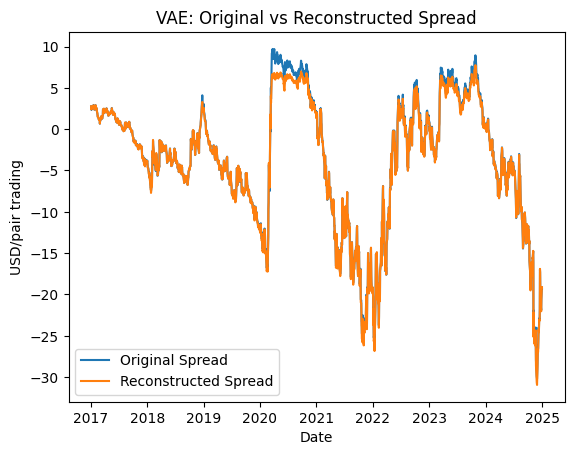

In [9]:
from plots.bocpd import vae_plot

vae_plot(test_spread, test_metrics['recons'])

## 7.2) **Drawdown for portfolio returns:**

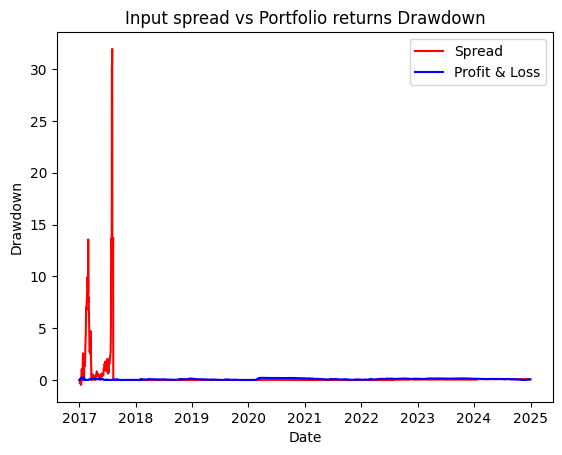

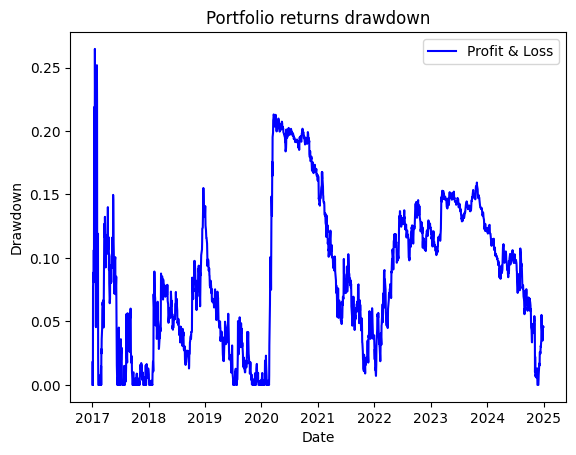

In [11]:
from plots.bocpd import drawdown_plot, compare_drawdown_plot

compare_drawdown_plot(test_spread.pct_change().dropna(), test_metrics['rets'])
drawdown_plot(test_metrics['rets'])

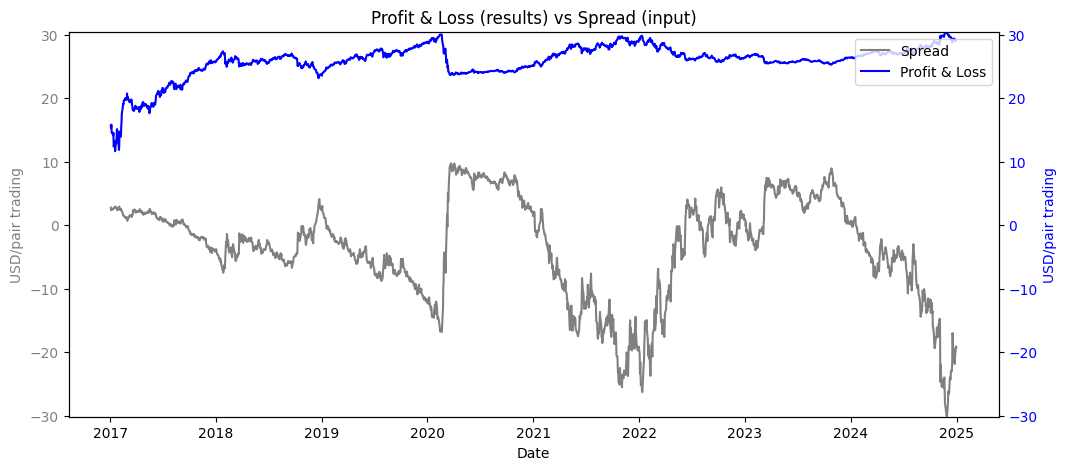

In [12]:
from plots.bocpd import compare_trends_plot

cumpnl = np.cumsum(test_metrics['portfolio_returns'])
compare_trends_plot(test_spread, cumpnl)

**From the plot:**

- Strategy P&L is consistently trending up: The blue line (P&L) shows a steady upward drift from 2017 to 2025. Even during volatile periods of the spread, the strategy maintains positive cumulative returns.
- The strategy is largely uncorrelated to the spread: The grey spread oscillates heavily, often diverging or mean-reverting, hitting large negative values. Meanwhile, the P&L remains smooth and upward, indicating the model is not simply betting on spread direction. It is learning structure/change-points rather than raw mean reversion.
- Sharpest P&L jump around 2020: There is a visible step-change upward around early 2020. This coincides with a dramatic spike in the spread, meaning the combined BOCPD + VAE features likely identified a regime break. The Transformer exploited the regime change well.
- Stable performance in later years despite spread worsening: From 2022-2025 the spread trends strongly downward, with large swings.P&L stays relatively flat but does not collapse, showing robustness to adverse spread behavior.

##**Summary:**

The model captures profitable short-term patterns in the spread without being directional or overexposed.

The P&L's smooth profile suggests:
- Good regularization
- Effective change-point conditioning
- Stable trading signals

## 7.3) **Change Probability over time plot for BOCPD+VAE+Transformer pipeline:**

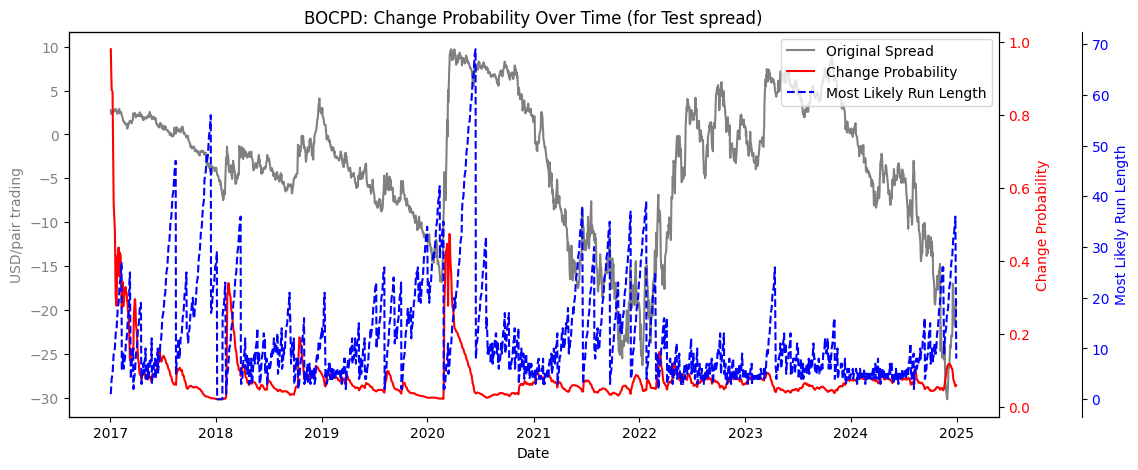

In [13]:
from plots.bocpd import plot_rt_change_probs

plot_rt_change_probs(test_spread, test_metrics['rt_mle'], test_metrics['change_probs'])